In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [8]:
trades=pd.read_csv('../data/historical_data.csv')
sentiment=pd.read_csv('../data/fear_greed_index.csv')

In [9]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [10]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [11]:
trades.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [12]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [13]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [14]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [15]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [16]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [26]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [29]:
trades['Timestamp IST'].isnull().sum()

np.int64(131999)

In [30]:
trades = trades.dropna(subset=['Timestamp IST'])

In [31]:
trades['Date'] = trades['Timestamp IST'].dt.date

In [32]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

sentiment['Date'] = sentiment['date'].dt.date

In [33]:
merged = pd.merge(
    trades,
    sentiment,
    on='Date',
    how='left'
)

In [34]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,2024-02-12


In [35]:
merged.shape

(79225, 21)

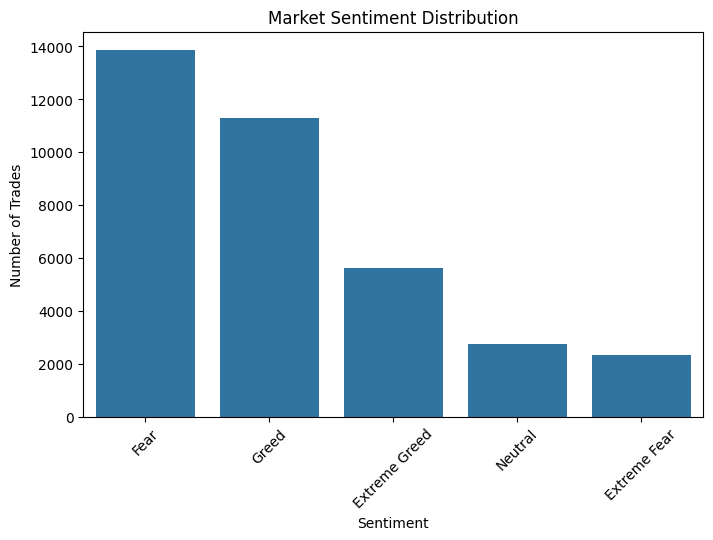

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='classification',
    data=merged,
    order=merged['classification'].value_counts().index
)

plt.title('Market Sentiment Distribution')

plt.xlabel('Sentiment')

plt.ylabel('Number of Trades')

plt.xticks(rotation=45)

plt.show()

Observation:
Trading activity varied significantly across different market sentiment phases, with higher participation observed during greed-driven periods.

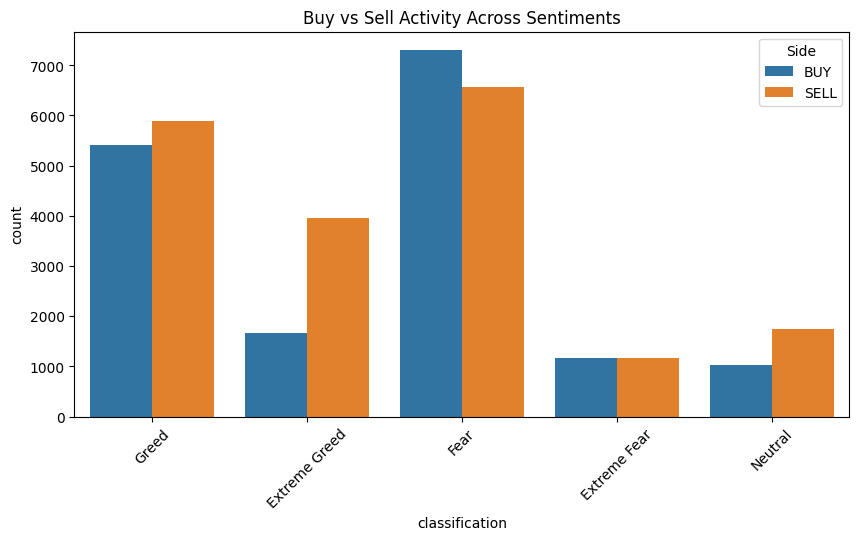

In [37]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='classification',
    hue='Side',
    data=merged
)

plt.title('Buy vs Sell Activity Across Sentiments')

plt.xticks(rotation=45)

plt.show()

Observation:
Buy and sell behavior shifted across sentiment phases, reflecting changing trader confidence and market psychology.

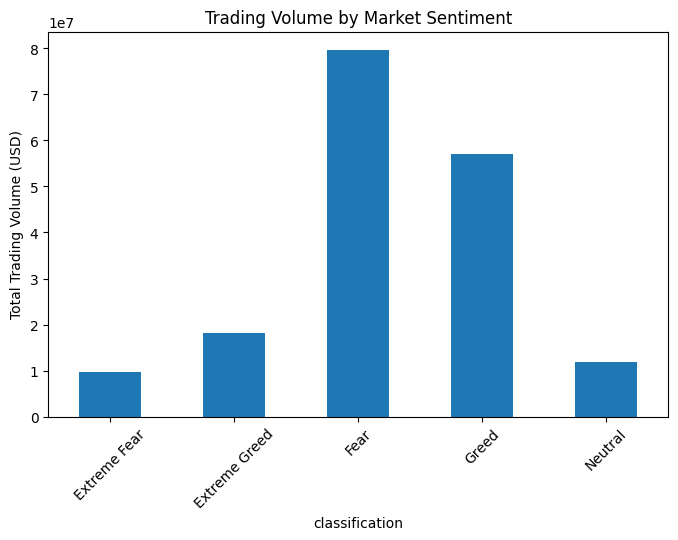

In [38]:
volume = merged.groupby('classification')['Size USD'].sum()

plt.figure(figsize=(8,5))

volume.plot(kind='bar')

plt.title('Trading Volume by Market Sentiment')

plt.ylabel('Total Trading Volume (USD)')

plt.xticks(rotation=45)

plt.show()

Observation:
Trading volume increased during emotionally charged market conditions, particularly during greed-driven phases.

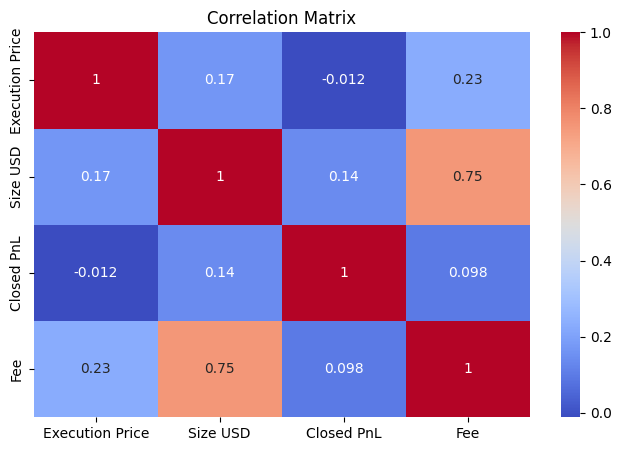

In [39]:
corr = merged[
    ['Execution Price', 'Size USD', 'Closed PnL', 'Fee']
].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

Observation:
Trade size and fees showed stronger correlation, while profitability displayed weaker direct correlation with execution price.

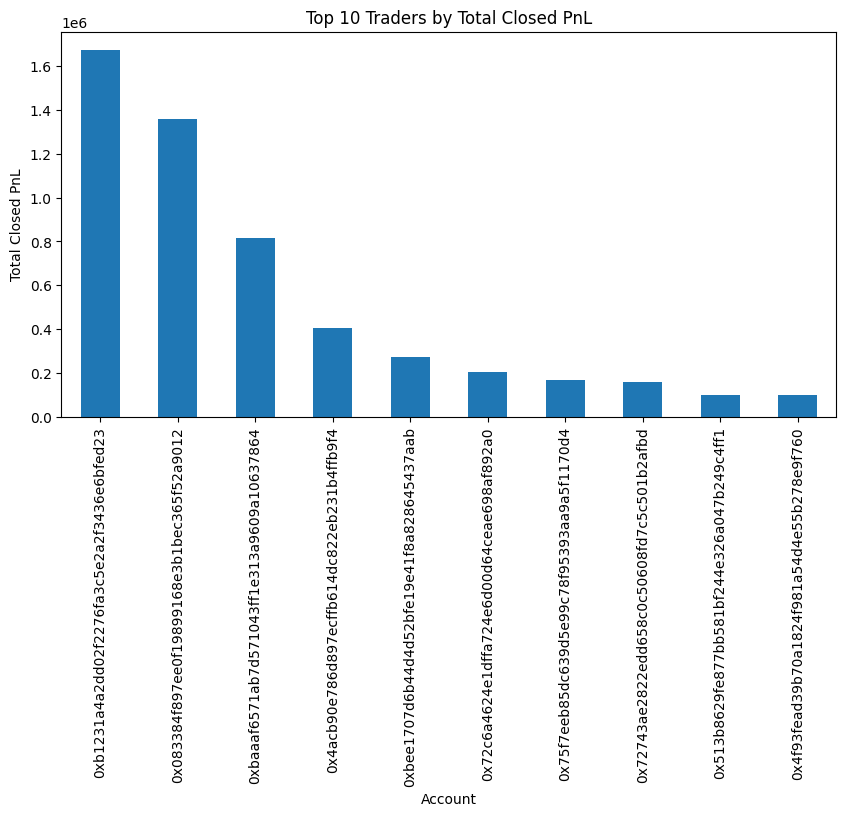

In [40]:
top_traders = merged.groupby('Account')['Closed PnL'].sum()

top_traders = top_traders.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

top_traders.plot(kind='bar')

plt.title('Top 10 Traders by Total Closed PnL')

plt.ylabel('Total Closed PnL')

plt.show()

Observation:
A small group of traders contributed disproportionately to overall profitability, indicating uneven performance distribution.

In [41]:
merged['Risk Score'] = (
    merged['Size USD'] / (merged['Fee'] + 1)
)

In [42]:
merged['Risk Category'] = pd.cut(
    merged['Risk Score'],
    bins=[0,100,1000,100000],
    labels=['Low','Medium','High']
)

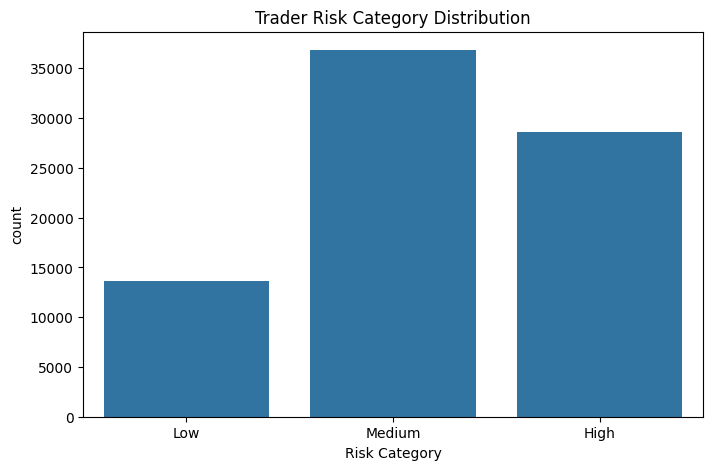

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Risk Category',
    data=merged
)

plt.title('Trader Risk Category Distribution')

plt.show()

### Observation

Most trades were concentrated within medium and high-risk categories, suggesting aggressive participation patterns in crypto trading environments.

C:\Users\Atharva Bandita\AppData\Local\Temp\ipykernel_5972\2414352548.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_pnl = merged.groupby(


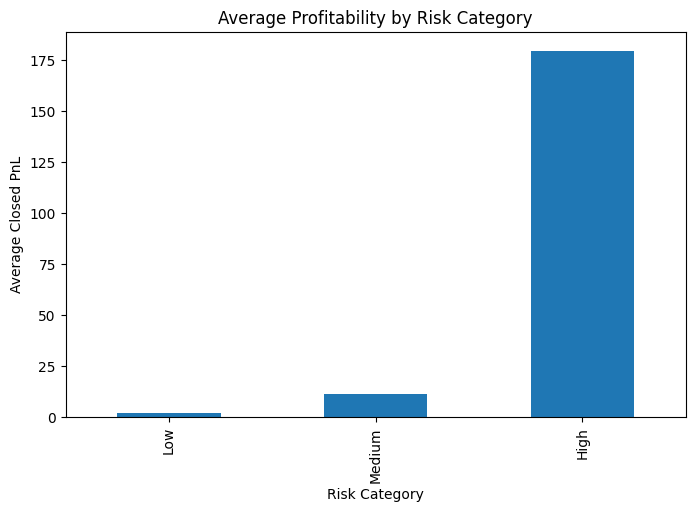

In [44]:
risk_pnl = merged.groupby(
    'Risk Category'
)['Closed PnL'].mean()

plt.figure(figsize=(8,5))

risk_pnl.plot(kind='bar')

plt.title('Average Profitability by Risk Category')

plt.ylabel('Average Closed PnL')

plt.show()

### Observation

Higher-risk trading categories showed greater variability in profitability, indicating increased exposure to market volatility.

# Key Insights

1. Market sentiment significantly influenced trader activity and trading volume.

2. Greed-driven periods showed higher market participation and larger trade volumes.

3. Profitability patterns varied across emotional market phases, indicating sentiment-driven decision making.

4. High-risk trading behavior was more common during emotionally charged market conditions.

5. A small group of traders contributed disproportionately to total profitability.

# Conclusion

This analysis demonstrates that market sentiment plays a major role in shaping trader behavior, risk appetite, and trading outcomes in crypto markets.

Greed-driven conditions encouraged higher participation and aggressive trading activity, while fear-based periods showed greater uncertainty and variability in trader performance.

The findings highlight how emotional market conditions influence both retail and large-scale trading behavior, emphasizing the importance of sentiment-aware trading strategies.